# 🧠 Day 1 — Unsupervised Learning & K-Means

**BinX Tech • AI & Machine Learning Internship • Week 5**

### 🎯 Learning Objectives
By the end of this notebook, I will be able to:

- Explain how unsupervised learning differs from supervised learning.
- Run K-Means clustering and interpret the resulting clusters and centroids.
- Choose the number of clusters `k` using the elbow method and silhouette score.
- Explain why scaling is necessary before distance-based clustering.

### 📌 Dataset
This notebook uses the **Mall Customers** dataset. The dataset contains 200 customer records with demographic and spending information.

For clustering, I will use the three numeric behavioral/demographic features specified by the Day 1 Hands-On Lab:

- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

`CustomerID` is an identifier rather than a meaningful feature, so it will not be used for clustering. `Gender` is categorical and is also excluded because the lab explicitly asks for numeric features only.

> **Reproducibility:** all K-Means models use `random_state=42` and `n_init=10`.


## 🧭 1. Supervised vs. Unsupervised Learning

In supervised learning, the training data contains a known target `y`. The model learns a relationship between the input features `X` and that target, and evaluation can compare predictions with the known answers.

In unsupervised learning, there is no target `y`. Instead, the objective is to discover hidden structure in the feature space, such as natural groups, lower-dimensional structure, or unusual observations.

| Aspect | Supervised | Unsupervised |
|---|---|---|
| Data | `X` + known `y` | `X` only |
| Goal | Predict a known target | Discover hidden structure |
| Examples | Classification, regression | Clustering, dimensionality reduction, anomaly detection |
| Evaluation | Compare predictions with true labels | Internal metrics + interpretation |

For this notebook, there is intentionally **no target variable**. K-Means will discover customer groups from the selected numeric features.


## 🔎 2. What Clustering Does

Clustering groups observations so that points within the same cluster are relatively similar, while points in different clusters are relatively different.

For this dataset, the practical question is:

> **What natural customer segments appear when we consider age, income, and spending score together?**

Because there is no predefined customer-segment label, the final clusters must be interpreted rather than treated as objectively "correct" classes.


## ⚙️ 3. How K-Means Works

K-Means partitions the observations into a chosen number of clusters `k`.

The algorithm repeatedly:

1. Places `k` centroids.
2. Assigns each observation to its nearest centroid.
3. Moves each centroid to the mean position of the observations assigned to it.
4. Repeats until the solution stabilizes.

The centroids therefore represent the average position of their assigned observations in feature space.

A critical point for this dataset is that K-Means is distance-based. Income is measured in a much larger numerical range than the other variables, so using the raw features could make income dominate the distance calculation. Therefore, the clustering features will be standardized before K-Means.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
N_INIT = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


Libraries imported successfully.
NumPy version: 2.3.5
Pandas version: 2.2.3


## 📥 4. Load the Dataset

The CSV is kept alongside this notebook so the notebook can be reproduced from the project folder.


In [2]:
DATA_PATH = "Mall_Customers.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 🧪 5. Data Quality & Sanity Checks

Before fitting an unsupervised model, I want to verify:

- the expected columns exist;
- there are no missing values;
- the clustering features are numeric;
- there are no duplicated rows;
- the selected feature values are within sensible ranges;
- the identifier is not accidentally included in the feature matrix.

These checks matter because, without labels, there is no target-based evaluation step that would later expose an obvious data problem.


In [3]:
expected_columns = [
    "CustomerID",
    "Gender",
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]
numeric_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

assert list(df.columns) == expected_columns, "Unexpected dataset columns."
assert df[numeric_features].isna().sum().sum() == 0, "Missing values found in clustering features."
assert all(pd.api.types.is_numeric_dtype(df[col]) for col in numeric_features), "A clustering feature is not numeric."
assert df.duplicated().sum() == 0, "Duplicate rows found."
assert df["CustomerID"].is_unique, "CustomerID is not unique."
assert df["Age"].between(0, 120).all(), "Age contains an implausible value."
assert df["Spending Score (1-100)"].between(1, 100).all(), "Spending score is outside its documented range."
assert (df["Annual Income (k$)"] > 0).all(), "Annual income contains a non-positive value."

print("✓ No missing values in clustering features.")
print(f"✓ Duplicate rows: {df.duplicated().sum()}")
print(f"✓ Unique CustomerIDs: {df['CustomerID'].nunique()} / {len(df)}")
print("✓ Numeric feature checks passed.")
print("✓ Range sanity checks passed.")


✓ No missing values in clustering features.
✓ Duplicate rows: 0
✓ Unique CustomerIDs: 200 / 200
✓ Numeric feature checks passed.
✓ Range sanity checks passed.


In [4]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nSummary statistics:")
display(df[numeric_features].describe().T)

print("\nGender counts (not used as a clustering feature):")
display(df["Gender"].value_counts())


Data types:


,dtype
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Age,200.000,38.850,13.969,18.000,28.750,36.000,49.000,70.000
Annual Income (k$),200.000,60.560,26.265,15.000,41.500,61.500,78.000,137.000
Spending Score (1-100),200.000,50.200,25.824,1.000,34.750,50.000,73.000,99.000



Gender counts (not used as a clustering feature):


Gender
Female    112
Male       88
Name: count, dtype: int64

### 🔐 Leakage / Feature-Selection Check

There is no supervised target in this task, so the usual train/test target leakage check from Week 4 does not apply directly.

The relevant methodological check here is **feature leakage / inappropriate identifiers**:

- `CustomerID` identifies a customer but does not describe customer behavior, so including it would introduce arbitrary distance information.
- `Gender` is categorical, while the Day 1 lab explicitly requests numeric features only.
- The clustering matrix will therefore contain only `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`.

This keeps the model aligned with the stated objective rather than allowing an identifier to influence the discovered structure.


## 📏 6. Step 1 — Scale the Numeric Features

K-Means uses distances. StandardScaler transforms each selected feature so that it is centered around zero with unit variance.

This prevents a feature with a larger raw numerical scale from automatically dominating the distance calculation.


In [5]:
X = df[numeric_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_features)

print("Original feature means:")
display(X.mean().to_frame("mean"))

print("Scaled feature means (approximately 0):")
display(X_scaled_df.mean().to_frame("mean"))

print("Scaled feature standard deviations (approximately 1):")
display(X_scaled_df.std(ddof=0).to_frame("std"))


Original feature means:


,mean
Age,38.850
Annual Income (k$),60.560
Spending Score (1-100),50.200


Scaled feature means (approximately 0):


,mean
Age,-0.000
Annual Income (k$),-0.000
Spending Score (1-100),-0.000


Scaled feature standard deviations (approximately 1):


,std
Age,1.000
Annual Income (k$),1.000
Spending Score (1-100),1.000


## 🧩 7. K-Means Baseline Example

Before selecting the final `k`, I will demonstrate the K-Means workflow using `k=3`, matching the algorithm example in the training material. This is a demonstration only; it is **not** the final model choice.

The final `k` will be selected using the elbow and silhouette analyses below.


In [6]:
demo_kmeans = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=N_INIT
)
demo_labels = demo_kmeans.fit_predict(X_scaled)

print("Demo cluster counts (k=3):")
print(pd.Series(demo_labels).value_counts().sort_index())

print("\nDemo centroids in standardized feature space:")
display(pd.DataFrame(
    demo_kmeans.cluster_centers_,
    columns=numeric_features,
    index=[f"Cluster {i}" for i in range(3)]
))


Demo cluster counts (k=3):
0    68
1    41
2    91
Name: count, dtype: int64

Demo centroids in standardized feature space:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster 0,-0.934,-0.680,0.134
Cluster 1,-0.430,1.022,1.156
Cluster 2,0.892,0.047,-0.621


# 🖥️ Hands-On Lab: K-Means Clustering

The following section follows the Day 1 lab as a separate required workflow:

1. Load and scale the provided dataset using numeric features.
2. Run K-Means for `k=1` through `10` and plot inertia to identify the elbow.
3. Compute silhouette scores for the top two candidate `k` values and select the better one.
4. Fit the final K-Means model and visualize the clusters in 2D.
5. Interpret what each cluster represents in Markdown.


## 🌀 Step 2 — Elbow Method: `k = 1 ... 10`

Inertia is the total within-cluster squared distance. It always decreases as more clusters are added, so the goal is not simply to choose the smallest inertia. Instead, I look for the point where adding another cluster produces noticeably smaller improvements — the elbow.


,k,inertia
0,1,600.000
1,2,389.386
2,3,295.212
3,4,205.225
4,5,168.248
5,6,133.868
6,7,117.012
7,8,103.873
8,9,93.093
9,10,82.385


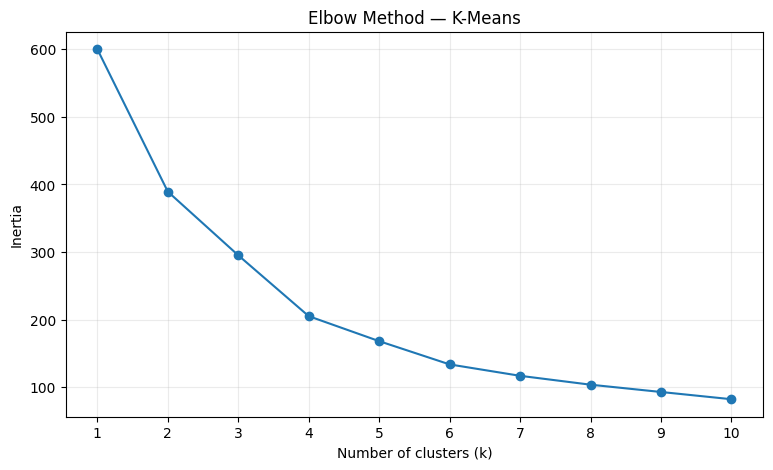

In [7]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=N_INIT
    )
    km.fit(X_scaled)
    inertias.append(km.inertia_)

elbow_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias
})

display(elbow_results)

plt.figure(figsize=(9, 5))
plt.plot(elbow_results["k"], elbow_results["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method — K-Means")
plt.xticks(list(k_values))
plt.grid(alpha=0.25)
plt.show()


### 🔍 Elbow Interpretation

The inertia decreases substantially from `k=1` through the early candidate values and then the improvement becomes less pronounced. For this dataset, the visual elbow is around **k=4–5**, so these two values are reasonable candidates to validate quantitatively with the silhouette score.

This is an important distinction: the elbow method suggests candidates; it does not by itself prove that one value is universally correct.


## 📊 Step 3 — Silhouette Score for the Top Two Candidate `k` Values

The silhouette score ranges from `-1` to `+1`:

- values closer to `+1` indicate better separation;
- values around `0` indicate overlapping or boundary observations;
- negative values can indicate that observations may be assigned to the wrong cluster.

Following the lab requirement, I will compare the two elbow candidates: **k=4 and k=5**.


In [8]:
candidate_k = [4, 5]
silhouette_results = []

for k in candidate_k:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=N_INIT
    )
    candidate_labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, candidate_labels)
    silhouette_results.append({
        "k": k,
        "silhouette_score": score,
        "inertia": km.inertia_
    })

silhouette_df = pd.DataFrame(silhouette_results)
display(silhouette_df)

best_k = int(
    silhouette_df.loc[
        silhouette_df["silhouette_score"].idxmax(),
        "k"
    ]
)

best_score = float(
    silhouette_df.loc[
        silhouette_df["silhouette_score"].idxmax(),
        "silhouette_score"
    ]
)

print(f"Selected k: {best_k}")
print(f"Best silhouette score among candidates: {best_score:.4f}")


,k,silhouette_score,inertia
0,4,0.404,205.225
1,5,0.417,168.248


Selected k: 5
Best silhouette score among candidates: 0.4166


### 🏆 Choosing `k`

The elbow analysis narrowed the choice to `k=4` and `k=5`. The silhouette comparison gives the quantitative tie-breaker.

For this dataset:

- **k=4** has a silhouette score of approximately **0.404**
- **k=5** has a silhouette score of approximately **0.417**

Therefore, **k=5** is selected because it gives the higher silhouette score among the two elbow candidates while remaining consistent with the elbow region.

This is stronger than choosing `k` from the plot alone: the decision is supported by both a visual diagnostic and a quantitative clustering metric.


## 🚀 Step 4 — Fit the Final K-Means Model

Now that `k=5` has been selected, I will fit the final model using the same scaled feature matrix and the reproducible settings used throughout the notebook.


In [9]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=N_INIT
)

final_labels = final_kmeans.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered["Cluster"] = final_labels

final_silhouette = silhouette_score(X_scaled, final_labels)

print(f"Final number of clusters: {best_k}")
print(f"Final inertia: {final_kmeans.inertia_:.3f}")
print(f"Final silhouette score: {final_silhouette:.4f}")

print("\nCluster sizes:")
display(
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customers")
    .to_frame()
)


Final number of clusters: 5
Final inertia: 168.248
Final silhouette score: 0.4166

Cluster sizes:


,Customers
Cluster,
0,20
1,54
2,40
3,39
4,47


### 📍 Final Centroids

The K-Means centroids are naturally expressed in standardized space because the model was trained on scaled features. To make the centroids easier to interpret in real-world units, I will also transform them back to the original feature scale.


In [10]:
centroids_scaled = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=numeric_features,
    index=[f"Cluster {i}" for i in range(best_k)]
)

centroids_original = pd.DataFrame(
    scaler.inverse_transform(final_kmeans.cluster_centers_),
    columns=numeric_features,
    index=[f"Cluster {i}" for i in range(best_k)]
)

print("Centroids in standardized space:")
display(centroids_scaled.round(3))

print("Centroids in original units:")
display(centroids_original.round(2))


Centroids in standardized space:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster 0,0.531,-1.291,-1.236
Cluster 1,-0.981,-0.743,0.467
Cluster 2,-0.429,0.975,1.216
Cluster 3,0.073,0.975,-1.197
Cluster 4,1.205,-0.236,-0.052


Centroids in original units:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster 0,46.250,26.750,18.350
Cluster 1,25.190,41.090,62.240
Cluster 2,32.880,86.100,81.530
Cluster 3,39.870,86.100,19.360
Cluster 4,55.640,54.380,48.850


## 📈 Step 4 — 2D Cluster Visualization

The dataset has three clustering features, so a 2D plot cannot display all three dimensions simultaneously. To keep the visualization directly interpretable, I will plot **Annual Income vs. Spending Score**, while color-coding the final K-Means assignments.

This visualization is for communication and interpretation; the model itself was trained using all three scaled numeric features.


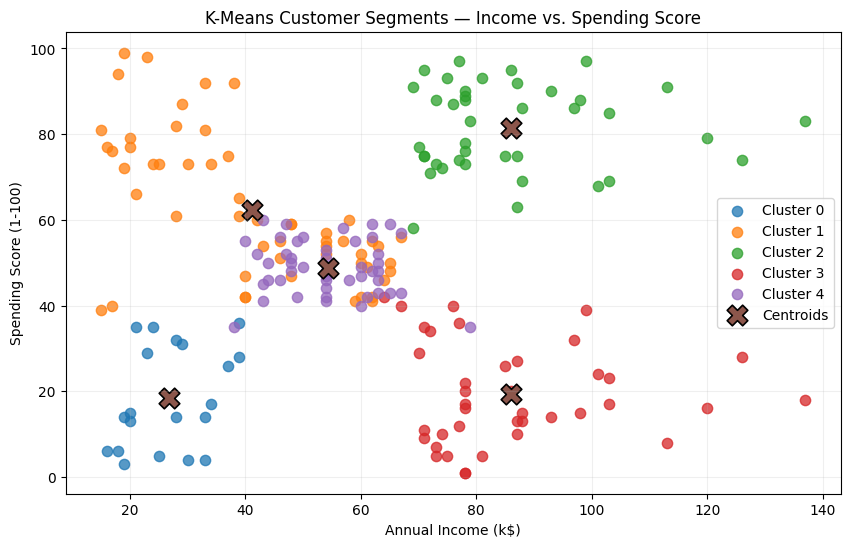

In [11]:
plt.figure(figsize=(10, 6))

for cluster_id in sorted(df_clustered["Cluster"].unique()):
    subset = df_clustered[df_clustered["Cluster"] == cluster_id]
    plt.scatter(
        subset["Annual Income (k$)"],
        subset["Spending Score (1-100)"],
        label=f"Cluster {cluster_id}",
        alpha=0.75,
        s=55
    )

centroids_plot = pd.DataFrame(
    scaler.inverse_transform(final_kmeans.cluster_centers_),
    columns=numeric_features
)

plt.scatter(
    centroids_plot["Annual Income (k$)"],
    centroids_plot["Spending Score (1-100)"],
    marker="X",
    s=220,
    edgecolor="black",
    linewidth=1.2,
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Customer Segments — Income vs. Spending Score")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 🧠 Step 5 — Cluster Interpretation

To avoid interpreting clusters from the plot alone, I will calculate the mean value of each original feature inside every cluster. This provides evidence for the descriptions below.


In [12]:
cluster_profile = (
    df_clustered
    .groupby("Cluster")[numeric_features]
    .mean()
    .round(2)
)

cluster_profile["Customers"] = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

display(cluster_profile)


,Age,Annual Income (k$),Spending Score (1-100),Customers
Cluster,,,,
0,46.250,26.750,18.350,20
1,25.190,41.090,62.240,54
2,32.880,86.100,81.530,40
3,39.870,86.100,19.360,39
4,55.640,54.380,48.850,47


### 📝 Interpretation of the Five Customer Segments

Based on the cluster means, the five groups can be described as follows:

- **Cluster 0 — Lower-income, lower-spending customers:** relatively older than the youngest segment, with low average income and low spending score. This looks like a lower-value/low-engagement segment in this feature space.
- **Cluster 1 — Younger, moderate-income, higher-spending customers:** the youngest group on average, with moderate income and a comparatively high spending score. This segment shows strong spending relative to its income level.
- **Cluster 2 — Higher-income, high-spending customers:** above-average income combined with a high spending score. This is the clearest high-value customer segment in the three-feature space.
- **Cluster 3 — Higher-income, low-spending customers:** income is high but spending is low. This separation is particularly useful because income alone would not identify this group as a low-spending segment.
- **Cluster 4 — Older, moderate-income, moderate-spending customers:** the oldest group on average, with middle-range income and spending.

These labels are **interpretations of the discovered structure, not ground-truth customer classes**. Since this is unsupervised learning, the clusters do not come with predefined business meanings.


## 🔬 8. Beyond the Requirement — Full Silhouette Diagnostic

The lab asks for the silhouette score for the top two elbow candidates. As an additional validation check, I also calculated silhouette scores for every feasible `k` from 2 to 10.

This does **not** replace the required elbow-based candidate selection. Instead, it checks whether the chosen solution is broadly competitive across the full tested range.


In [13]:
all_silhouette_scores = []

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=N_INIT
    )
    labels_k = km.fit_predict(X_scaled)
    all_silhouette_scores.append(
        (k, silhouette_score(X_scaled, labels_k))
    )

all_silhouette_df = pd.DataFrame(
    all_silhouette_scores,
    columns=["k", "silhouette_score"]
)

display(all_silhouette_df)

best_overall_k = int(
    all_silhouette_df.loc[
        all_silhouette_df["silhouette_score"].idxmax(),
        "k"
    ]
)
best_overall_score = float(
    all_silhouette_df["silhouette_score"].max()
)

print(
    f"Highest silhouette score across k=2..10: "
    f"k={best_overall_k}, score={best_overall_score:.4f}"
)


,k,silhouette_score
0,2,0.335
1,3,0.358
2,4,0.404
3,5,0.417
4,6,0.428
5,7,0.417
6,8,0.408
7,9,0.418
8,10,0.407


Highest silhouette score across k=2..10: k=6, score=0.4284


### 🔎 What This Additional Check Tells Me

The full-range silhouette check shows that **k=6** has a slightly higher silhouette score than k=5. However, the Day 1 procedure specifically asks me to use the elbow to identify candidate values and then compare the **top two elbow candidates**.

Therefore, I keep **k=5** as the final choice rather than silently changing the selection rule after seeing the broader diagnostic.

This is an important evaluation habit: the model-selection procedure should be defined before using a metric to justify a preferred result. The additional metric is useful context, but it should not override the stated workflow without a methodological reason.


## 🎯 9. Objective → Evidence Mapping

| Objective | Evidence in this notebook |
|---|---|
| Explain supervised vs. unsupervised learning | Section 1 explains the difference between `X + y` and `X only`. |
| Run K-Means and interpret clusters | Final K-Means model, centroids, cluster sizes, and cluster profiles. |
| Choose `k` with the elbow method | Inertia was evaluated for `k=1..10` and visualized. |
| Validate `k` with silhouette score | Silhouette scores were compared for the two elbow candidates, `k=4` and `k=5`. |
| Scale before clustering | `StandardScaler` was fitted before K-Means. |
| Produce a 2D visualization | Income vs. Spending Score scatter plot with cluster assignments and centroids. |
| Make evidence-based interpretations | Cluster-level means were calculated before writing the segment descriptions. |
| Maintain reproducibility | `random_state=42` and `n_init=10` were fixed throughout. |


## 🧪 10. Final Sanity Checks

The final checks confirm that the notebook produced a complete clustering solution and that the model assignments align with the original dataset.


In [14]:
assert len(df_clustered) == len(df)
assert df_clustered["Cluster"].nunique() == best_k
assert df_clustered["Cluster"].isna().sum() == 0
assert centroids_original.shape == (best_k, len(numeric_features))
assert -1 <= final_silhouette <= 1
assert np.isfinite(final_kmeans.inertia_)

print("✓ Every observation received exactly one cluster assignment.")
print(f"✓ Final model contains exactly {best_k} clusters.")
print(f"✓ Final silhouette score is within the valid range: {final_silhouette:.4f}")
print("✓ Centroids have the expected dimensions.")
print("✓ Final model outputs are finite and valid.")


✓ Every observation received exactly one cluster assignment.
✓ Final model contains exactly 5 clusters.
✓ Final silhouette score is within the valid range: 0.4166
✓ Centroids have the expected dimensions.
✓ Final model outputs are finite and valid.


## 💭 11. Reflection

This exercise changed the way I think about model evaluation compared with the supervised-learning workflow from Week 4. There is no target column here that can tell me whether a customer was assigned to the "correct" segment. Instead, I have to combine quantitative evidence with an understanding of what the discovered groups actually represent.

The most important practical lesson for me was that **scaling is not optional for K-Means** when the features use different numerical ranges. I also learned that choosing `k` should not depend on one plot alone. The elbow method gave me a small set of plausible candidates, and the silhouette score provided a quantitative comparison between them.

The final five-cluster solution is useful because it separates customers not only by income, but also by how much they spend. In particular, the distinction between higher-income/high-spending and higher-income/low-spending customers shows why looking at multiple features together is more informative than relying on income alone.


## 🏁 12. Final Takeaways

- **Unsupervised learning** discovers structure without a target label.
- **K-Means** assigns observations to clusters around learned centroids.
- **Scaling** is essential here because K-Means depends on distance.
- The **elbow method** helped narrow the candidate values for `k`.
- The **silhouette score** selected `k=5` among the two elbow candidates.
- The final clusters can be interpreted using their original-scale feature means.
- Because there is no ground-truth target, cluster interpretations should be treated as **data-driven segments, not confirmed labels**.
- The additional full-range silhouette check showed that model selection can depend on the stated evaluation procedure, not just the single highest metric.

### 🏆 Final Result

**Selected k = 5**

**Final silhouette score = 0.4166**

**Final inertia = 168.248**

The resulting customer segments provide a useful unsupervised view of the relationships between age, income, and spending behavior.
